In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

In [3]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [4]:
target = "house_price_inr"



PART H : BIAS VARIANCE


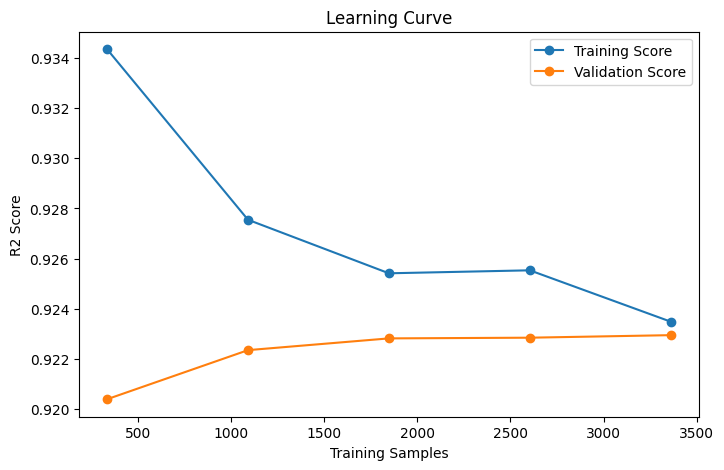

In [5]:
df_clean = df.copy()

print("\n")
print("="*60)
print("PART H : BIAS VARIANCE")
print("="*60)

X = df_clean.drop(columns=[target,'house_id'])
y = df_clean[target]

model = LinearRegression()

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

train_mean = np.mean(train_scores,axis=1)
test_mean = np.mean(test_scores,axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()